In [24]:
# Import Libraries
import pandas as pd
import numpy as np
import os
import warnings

import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [25]:
# Import dataset
df = pd.read_csv('Dataset.csv')

In [26]:
df.head(5)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   instant     17379 non-null  int64 
 1   dteday      17379 non-null  object
 2   season      17379 non-null  object
 3   yr          17379 non-null  object
 4   mnth        17379 non-null  object
 5   hr          17379 non-null  int64 
 6   holiday     17379 non-null  object
 7   weekday     17379 non-null  int64 
 8   workingday  17379 non-null  object
 9   weathersit  17379 non-null  object
 10  temp        17379 non-null  object
 11  atemp       17379 non-null  object
 12  hum         17379 non-null  object
 13  windspeed   17379 non-null  object
 14  casual      17379 non-null  object
 15  registered  17379 non-null  object
 16  cnt         17379 non-null  int64 
dtypes: int64(4), object(13)
memory usage: 2.3+ MB


In [28]:
df.describe()

,instant,hr,weekday,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000
mean,8690.0000,11.546752,3.003683,189.463088
std,5017.0295,6.914405,2.005771,181.387599
min,1.0000,0.000000,0.000000,1.000000
25%,4345.5000,6.000000,1.000000,40.000000
50%,8690.0000,12.000000,3.000000,142.000000
75%,13034.5000,18.000000,5.000000,281.000000
max,17379.0000,23.000000,6.000000,977.000000


In [29]:
# Check missing values
df.isnull().sum()  # we don't have any null values


instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [30]:
# Throughout the dataset we have '?' marks
# That's why we got nulls as zero; we have to replace them with NaN
df.replace({'?': np.nan}, inplace=True)

cols = ['temp', 'atemp', 'hum', 'windspeed']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [31]:
df.isnull().sum()

instant        0
dteday         0
season         6
yr             1
mnth           1
hr             0
holiday        1
weekday        0
workingday     5
weathersit     4
temp          11
atemp          6
hum            6
windspeed      5
casual         1
registered     1
cnt            0
dtype: int64

In [32]:
df.shape[0]

17379

In [33]:
df.dropna(inplace=True)

In [34]:
df.isnull().sum().sum()

0

In [35]:
df.shape[0]

17339

In [36]:
df.duplicated().sum()

0

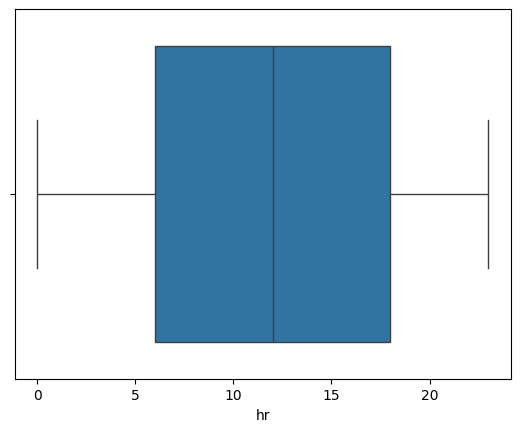

In [37]:
sns.boxplot(x=df['hr']); plt.show()

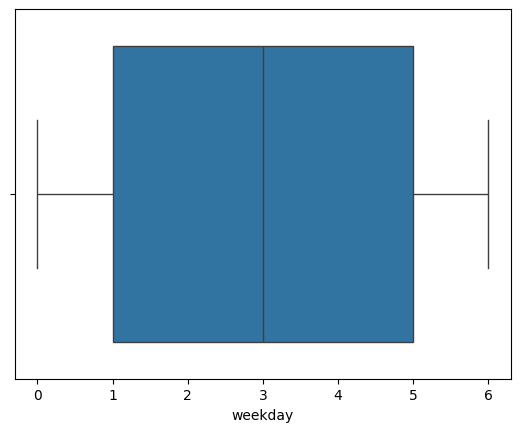

In [38]:
sns.boxplot(x=df['weekday']); plt.show()

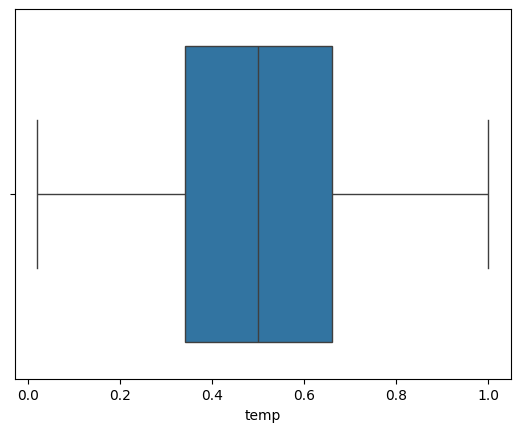

In [39]:
sns.boxplot(x=df['temp']); plt.show()

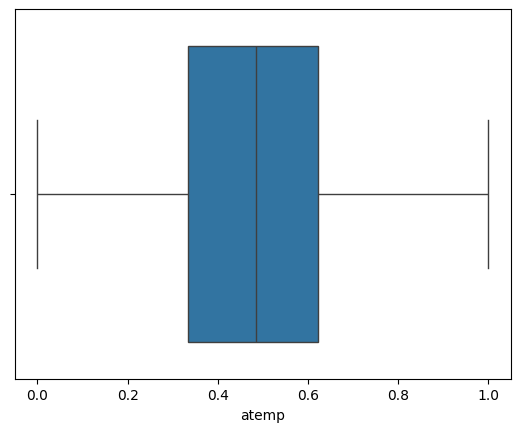

In [40]:
sns.boxplot(x=df['atemp']); plt.show()

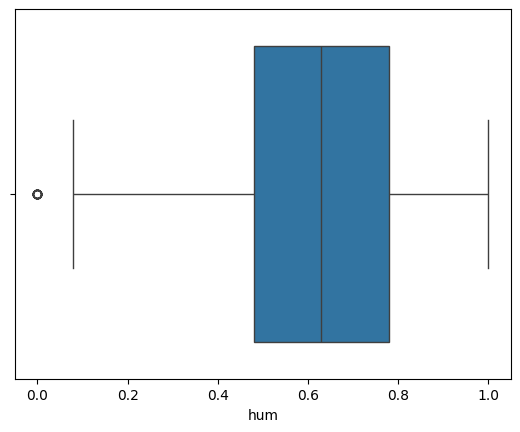

In [41]:
sns.boxplot(x=df['hum']); plt.show()

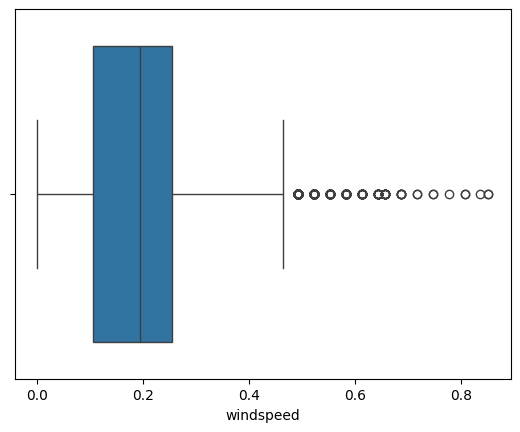

In [42]:
sns.boxplot(x=df['windspeed']); plt.show()

In [43]:
# Drop instant (index col), dteday (already have yr/mnth/weekday),
# casual and registered (they sum to cnt — would be data leakage)
df.drop(columns=['instant', 'dteday', 'casual', 'registered'], inplace=True)


In [44]:
df.columns

Index(['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

In [45]:
df = df.replace('springer', 'spring')

In [46]:
df['season'].unique()

array(['spring', 'summer', 'fall', 'winter'], dtype=object)

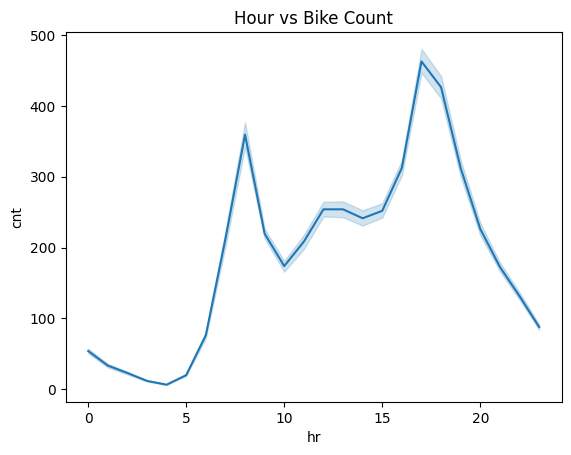

In [47]:
sns.lineplot(x=df['hr'], y=df['cnt'])
plt.title('Hour vs Bike Count')
plt.show()


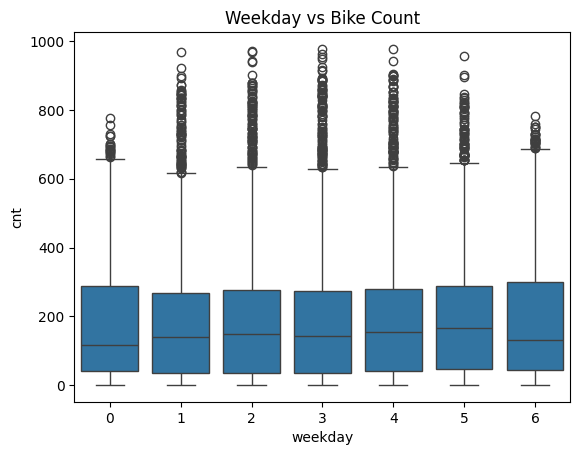

In [48]:
sns.boxplot(x=df['weekday'], y=df['cnt'])
plt.title('Weekday vs Bike Count')
plt.show()


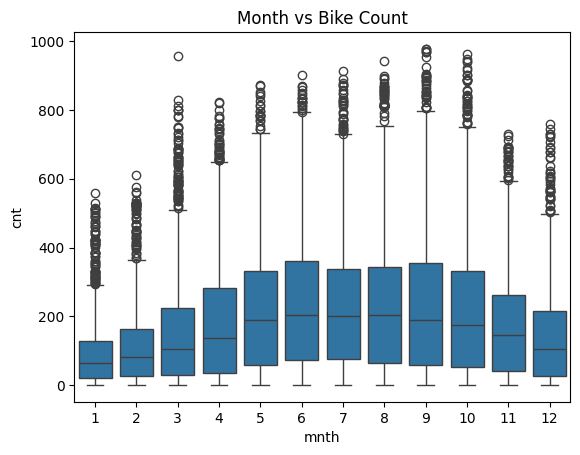

In [49]:
sns.boxplot(x=df['mnth'], y=df['cnt'])
plt.title('Month vs Bike Count')
plt.show()


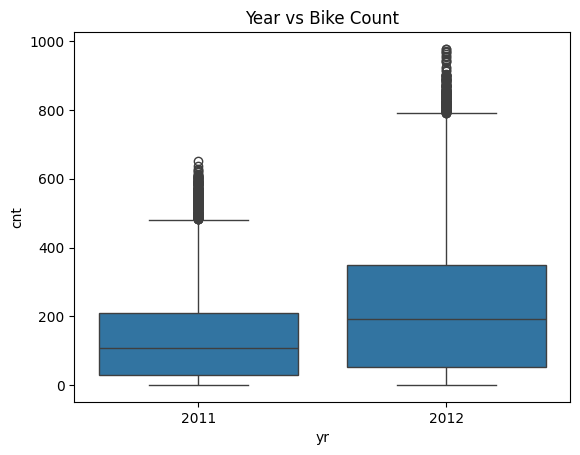

In [50]:
sns.boxplot(x=df['yr'], y=df['cnt'])
plt.title('Year vs Bike Count')
plt.show()


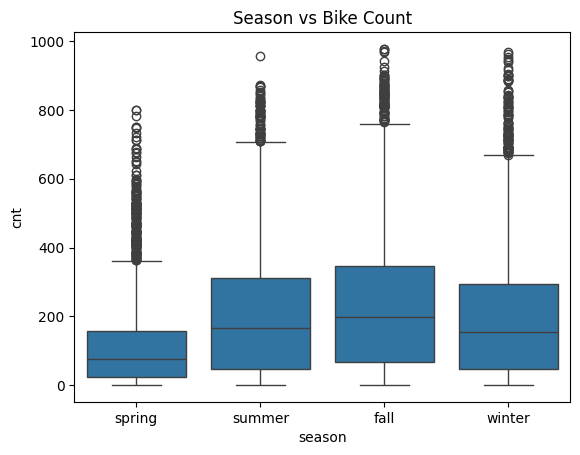

In [51]:
sns.boxplot(x=df['season'], y=df['cnt'])
plt.title('Season vs Bike Count')
plt.show()


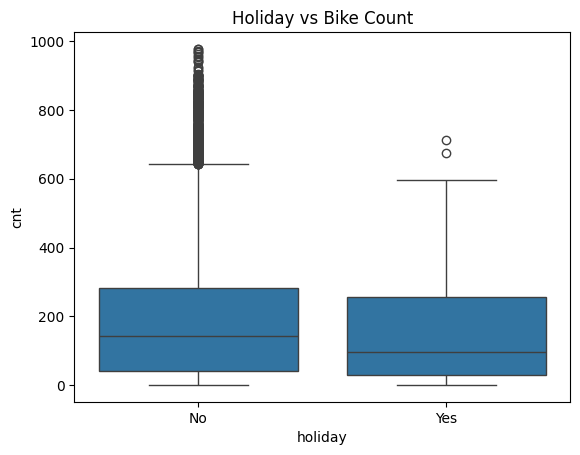

In [52]:
sns.boxplot(x=df['holiday'], y=df['cnt'])
plt.title('Holiday vs Bike Count')
plt.show()


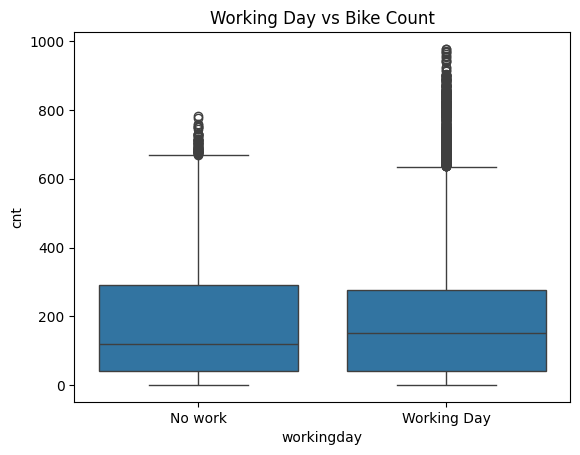

In [53]:
sns.boxplot(x=df['workingday'], y=df['cnt'])
plt.title('Working Day vs Bike Count')
plt.show()


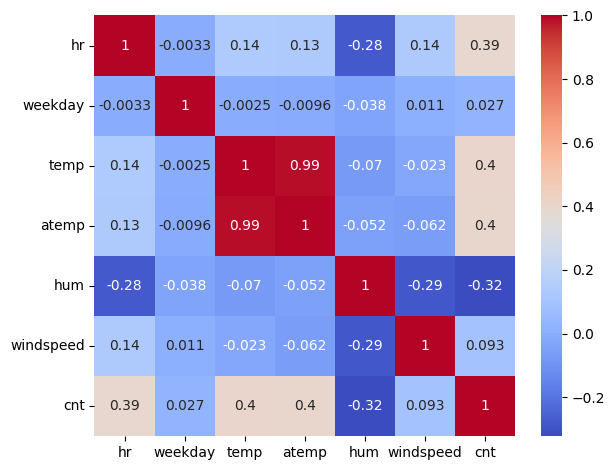

In [54]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.tight_layout()
plt.show()


In [55]:
df.corr(numeric_only=True)

,hr,weekday,temp,atemp,hum,windspeed,cnt
hr,1.000000,-0.003263,0.138133,0.134350,-0.276567,0.136776,0.394596
weekday,-0.003263,1.000000,-0.002482,-0.009553,-0.037595,0.011040,0.026816
temp,0.138133,-0.002482,1.000000,0.987649,-0.069647,-0.023301,0.403930
atemp,0.134350,-0.009553,0.987649,1.000000,-0.051756,-0.062328,0.400103
hum,-0.276567,-0.037595,-0.069647,-0.051756,1.000000,-0.289933,-0.322800
windspeed,0.136776,0.011040,-0.023301,-0.062328,-0.289933,1.000000,0.093337
cnt,0.394596,0.026816,0.403930,0.400103,-0.322800,0.093337,1.000000


## Feature Engineering

In [56]:
# is_weekend: weekends have leisure-driven demand vs commute-driven weekdays
df['is_weekend'] = df['weekday'].isin([0, 6]).astype(int)


We created `is_weekend` to distinguish weekdays from weekends.
User behaviour differs significantly — weekends skew toward leisure, weekdays toward commuting.


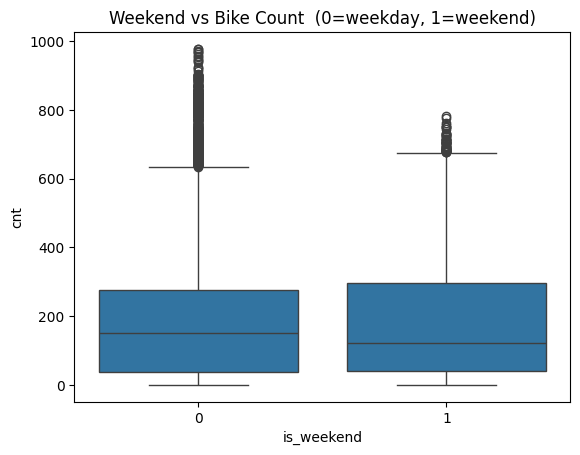

In [57]:
sns.boxplot(x=df['is_weekend'], y=df['cnt'])
plt.title('Weekend vs Bike Count  (0=weekday, 1=weekend)')
plt.show()


On weekdays, demand is consistent and commute-driven.
Weekends show higher variability based on personal plans and weather.


In [58]:
# time_of_day: bin hours into four periods
df['time_of_day'] = pd.cut(
    df['hr'],
    bins=[0, 6, 12, 18, 24],
    labels=['night', 'morning', 'afternoon', 'evening'],
    right=True,
    include_lowest=True
)


`time_of_day` groups hours into night / morning / afternoon / evening,
capturing daily usage patterns (demand peaks during commute windows).


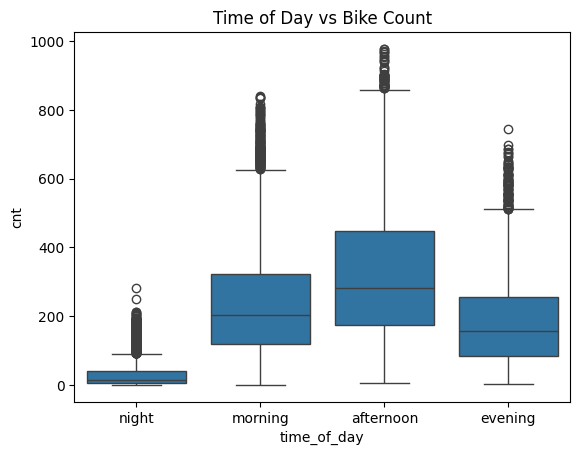

In [59]:
sns.boxplot(x=df['time_of_day'], y=df['cnt'])
plt.title('Time of Day vs Bike Count')
plt.show()


Higher morning and evening demand reflects office commutes;
afternoon peaks may be outdoor activities in favourable conditions.


In [60]:
# Interaction feature: combined effect of temperature and humidity on comfort
df['temp_humidity'] = df['temp'] * df['hum']


In [61]:
df.columns

Index(['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'is_weekend',
       'time_of_day', 'temp_humidity'],
      dtype='object')

## Handling Categorical Variables (Encoding)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17339 entries, 0 to 17377
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   season         17339 non-null  object  
 1   yr             17339 non-null  object  
 2   mnth           17339 non-null  object  
 3   hr             17339 non-null  int64   
 4   holiday        17339 non-null  object  
 5   weekday        17339 non-null  int64   
 6   workingday     17339 non-null  object  
 7   weathersit     17339 non-null  object  
 8   temp           17339 non-null  float64 
 9   atemp          17339 non-null  float64 
 10  hum            17339 non-null  float64 
 11  windspeed      17339 non-null  float64 
 12  cnt            17339 non-null  int64   
 13  is_weekend     17339 non-null  int64   
 14  time_of_day    17339 non-null  category
 15  temp_humidity  17339 non-null  float64 
dtypes: category(1), float64(5), int64(4), object(6)
memory usage: 2.1+ MB


In [63]:
# One-hot encode — drop_first=True avoids multicollinearity
df = pd.get_dummies(df, columns=[
    'season', 'yr', 'mnth', 'holiday', 'workingday', 'weathersit', 'time_of_day'
], drop_first=True)


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17339 entries, 0 to 17377
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   hr                      17339 non-null  int64  
 1   weekday                 17339 non-null  int64  
 2   temp                    17339 non-null  float64
 3   atemp                   17339 non-null  float64
 4   hum                     17339 non-null  float64
 5   windspeed               17339 non-null  float64
 6   cnt                     17339 non-null  int64  
 7   is_weekend              17339 non-null  int64  
 8   temp_humidity           17339 non-null  float64
 9   season_spring           17339 non-null  bool   
 10  season_summer           17339 non-null  bool   
 11  season_winter           17339 non-null  bool   
 12  yr_2012                 17339 non-null  bool   
 13  mnth_10                 17339 non-null  bool   
 14  mnth_11                 17339 non-null  boo

Categorical variables are one-hot encoded (not label-encoded) because they have no
inherent ordinal relationship. `drop_first=True` prevents the dummy-variable trap.


In [65]:
from sklearn.preprocessing import StandardScaler

num_cols = ['temp', 'atemp', 'hum', 'windspeed']
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


In [66]:
df[num_cols].head()

,temp,atemp,hum,windspeed
0,-1.338364,-1.096937,0.947469,-1.554187
1,-1.442304,-1.185455,0.895652,-1.554187
3,-1.338364,-1.096937,0.636568,-1.554187
4,-1.338364,-1.096937,0.636568,-1.554187
5,-1.338364,-1.273390,0.636568,-0.821553


Numerical features are scaled with `StandardScaler` to bring them to a common scale,
which benefits linear models and prevents bias toward high-magnitude features.


In [67]:
df[num_cols].mean().round(6)

temp        -0.0
atemp       -0.0
hum         -0.0
windspeed   -0.0
dtype: float64

In [68]:
df[num_cols].std().round(4)

temp         1.0
atemp        1.0
hum          1.0
windspeed    1.0
dtype: float64

## Model Building

In [69]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['cnt'])
y = df['cnt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (13871, 31), Test: (3468, 31)


### Training Models

#### Linear Regression

In [70]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression trained.")


Linear Regression trained.


#### Decision Tree

In [71]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree trained.")


Decision Tree trained.


#### Random Forest

In [72]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest trained.")


Random Forest trained.


#### Gradient Boosting

In [73]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
print("Gradient Boosting trained.")


Gradient Boosting trained.


## Model Evaluation

In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, model):
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    mse  = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, preds)
    return [name, round(mae, 4), round(mse, 4), round(rmse, 4), round(r2, 4)]


In [75]:
results = [
    evaluate_model("Linear Regression",  lr_model),
    evaluate_model("Decision Tree",       dt_model),
    evaluate_model("Random Forest",       rf_model),
    evaluate_model("Gradient Boosting",   gb_model),
]

results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R²"])
results_df


,Model,MAE,MSE,RMSE,R²
0,Linear Regression,92.1614,14783.4665,121.5873,0.5528
1,Decision Tree,35.4295,3672.1476,60.5982,0.8889
2,Random Forest,25.7196,1775.0116,42.1309,0.9463
3,Gradient Boosting,49.8074,5343.0464,73.0961,0.8384


## Hyperparameter Tuning — Grid Search for Random Forest

In [76]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 10, 20],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV R²: ", round(grid_search.best_score_, 4))


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'max_depth': None, 'n_estimators': 200}
Best CV R²:  0.9375


In [77]:
best_rf = grid_search.best_estimator_
print("Tuned RF evaluation:", evaluate_model("Random Forest (Tuned)", best_rf))


Tuned RF evaluation: ['Random Forest (Tuned)', 25.6757, 1772.3119, 42.0988, 0.9464]


### Cross-Validation Performance

In [78]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='r2')
print(f"CV R² scores: {cv_scores.round(4)}")
print(f"Mean CV R²:   {cv_scores.mean():.4f}")


CV R² scores: [0.9397 0.9448 0.9368 0.9444 0.9383]
Mean CV R²:   0.9408


## Final Model Comparison (including tuned RF)

In [79]:
final_results = [
    evaluate_model("Linear Regression",    lr_model),
    evaluate_model("Decision Tree",         dt_model),
    evaluate_model("Random Forest",         rf_model),
    evaluate_model("Gradient Boosting",     gb_model),
    evaluate_model("Random Forest (Tuned)", best_rf),
]

final_df = pd.DataFrame(final_results, columns=["Model", "MAE", "MSE", "RMSE", "R²"])
final_df_sorted = final_df.sort_values("R²", ascending=False).reset_index(drop=True)
final_df_sorted


,Model,MAE,MSE,RMSE,R²
0,Random Forest (Tuned),25.6757,1772.3119,42.0988,0.9464
1,Random Forest,25.7196,1775.0116,42.1309,0.9463
2,Decision Tree,35.4295,3672.1476,60.5982,0.8889
3,Gradient Boosting,49.8074,5343.0464,73.0961,0.8384
4,Linear Regression,92.1614,14783.4665,121.5873,0.5528


## Save Artifacts for Streamlit Deployment

In [80]:
import joblib
from pathlib import Path

# ── Create artifacts directory ─────────────────────────────────────────────────
artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(exist_ok=True)

# ── Identify best model by R² ──────────────────────────────────────────────────
best_model_name = final_df_sorted.iloc[0]['Model']
model_map = {
    'Linear Regression':    lr_model,
    'Decision Tree':         dt_model,
    'Random Forest':         rf_model,
    'Gradient Boosting':     gb_model,
    'Random Forest (Tuned)': best_rf,
}
best_model = model_map[best_model_name]
print(f"Best model: {best_model_name}  (R² = {final_df_sorted.iloc[0]['R²']})")

# ── Save model ─────────────────────────────────────────────────────────────────
joblib.dump(best_model, artifacts_dir / 'model.pkl')
print("Saved: artifacts/model.pkl")

# ── Save scaler ────────────────────────────────────────────────────────────────
joblib.dump(scaler, artifacts_dir / 'scaler.pkl')
print("Saved: artifacts/scaler.pkl")

# ── Save feature column order ──────────────────────────────────────────────────
feature_columns = list(X.columns)
joblib.dump(feature_columns, artifacts_dir / 'feature_columns.pkl')
print(f"Saved: artifacts/feature_columns.pkl  ({len(feature_columns)} features)")

# ── Save model comparison CSV ──────────────────────────────────────────────────
final_df_sorted.to_csv(artifacts_dir / 'model_results.csv', index=False)
print("Saved: artifacts/model_results.csv")

print("\n✅ All artifacts saved successfully!")


Best model: Random Forest (Tuned)  (R² = 0.9464)
Saved: artifacts/model.pkl
Saved: artifacts/scaler.pkl
Saved: artifacts/feature_columns.pkl  (31 features)
Saved: artifacts/model_results.csv

✅ All artifacts saved successfully!


In [81]:
# ── Verification ───────────────────────────────────────────────────────────────
print("=== Artifact verification ===")
for f in sorted(artifacts_dir.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<30}  {size_kb:>8.1f} KB")

# Quick sanity-check: reload and predict one sample
model_check  = joblib.load(artifacts_dir / 'model.pkl')
scaler_check = joblib.load(artifacts_dir / 'scaler.pkl')
cols_check   = joblib.load(artifacts_dir / 'feature_columns.pkl')

sample = X_test.iloc[[0]]
pred   = model_check.predict(sample)[0]
print(f"\nSanity check prediction: {pred:.2f}  (actual: {y_test.iloc[0]})")
print("\n✅ Notebook complete — ready for Streamlit deployment.")


=== Artifact verification ===
  feature_columns.pkl                  0.4 KB
  model.pkl                       232918.8 KB
  model_results.csv                    0.3 KB
  scaler.pkl                           0.9 KB

Sanity check prediction: 215.93  (actual: 195)

✅ Notebook complete — ready for Streamlit deployment.
